---
date: "2026-04-19"
date-modified: last-modified
format:
  html:
    toc: true
---


# Gambler's Ruin

## 1\. Problem Formulation

Two gamblers, **A** and **B**, are playing a game together until one of them goes completely bankrupt.

  * Each round, they bet exactly $\$1$.
  * **$p$**: The probability that Gambler A wins a certain round.
  * **$q = 1-p$**: The probability that Gambler B wins a certain round.
  * They repeat this forever until one reaches $\$0$.

**Initial Conditions:** Let $N$ be the total amount of money in the game. Gambler A starts with $i$ dollars, and Gambler B starts with $(N-i)$ dollars.

**The Goal:**
Find the exact probability that Gambler A wins the entire game (meaning Gambler B is ruined, and A ends up with all $N$ dollars).

**The Random Walk Analogy:**
You can visualize this problem as a 1-Dimensional Random Walk. Imagine a character standing on a number line at position $i$.

  * At each time step, with probability $p$, they take $1$ step to the right ($i \to i+1$).
  * With probability $q$, they jump $1$ step to the left ($i \to i-1$).
  * The points $0$ and $N$ are **absorbing states**. Once the character hits $0$ or $N$, the game immediately halts.

-----

## 2\. Setting Up the Difference Equation (First Step Analysis)

Let $p_i$ be the probability that A wins the entire game, given that A currently has $i$ dollars:
$$p_i = P(\text{A wins game} \mid \text{A starts with } i \text{ dollars})$$

We can solve this using **First Step Analysis**. By applying the [LoTP](law-of-total-probability.ipynb) (Law of Total Probability), we condition our ultimate success on the outcome of the very first round.

Because a single round only has two possible outcomes, the events "A wins the first round" and "A loses the first round" are mutually exclusive (disjoint) and exhaustive. Together, they form a proper partition of the sample space. This allows us to apply the **Law of Total Probability**:

$$P(\text{A wins game}) = P(\text{A wins game} \mid \text{A wins round 1}) \cdot P(\text{A wins round 1}) + P(\text{A wins game} \mid \text{A loses round 1}) \cdot P(\text{A loses round 1})$$

Breaking this down into our two specific scenarios:

1. **A wins the first round (probability $p$):** A's wealth increases to $i+1$. Because the game is memoryless (a Markov process), the history doesn't matter; the probability of A winning the overall game from this new state is exactly $p_{i+1}$.
2. **A loses the first round (probability $q$):** A's wealth decreases to $i-1$. By the same logic, the new probability of winning the game from this state is $p_{i-1}$.

Substituting these values back into our Law of Total Probability formula yields our foundational difference equation:

$$p_i = p \cdot p_{i+1} + q \cdot p_{i-1}, \quad \text{for } 1 \leq i \leq N-1$$

We also have two critical **boundary conditions** based on the absorbing states:

* $p_0 = 0$ (If A reaches $\$0$, A is ruined, so the probability of A winning the game is $0$).
* $p_N = 1$ (If A reaches $\$N$, B is ruined, so A has already won with $100\%$ certainty).

-----

## 3\. Solving the Difference Equation

To solve this, we can rearrange our equation into a standard [second-order linear homogeneous difference equation](second-order-linear-difference-equations.ipynb):
$$p \cdot p_{i+1} - p_i + q \cdot p_{i-1} = 0$$

Assuming a solution of the form $p_i = \lambda^i$, we obtain the characteristic equation:
$$p \lambda^2 - \lambda + q = 0$$

Since $p + q = 1$, we can rewrite the middle term $-\lambda$ as $-(p+q)\lambda$:
$$p \lambda^2 - (p+q)\lambda + q = 0$$
$$(p\lambda - q)(\lambda - 1) = 0$$

This yields two characteristic roots:
$$\lambda_1 = 1 \quad \text{and} \quad \lambda_2 = \frac{q}{p}$$

Because the roots depend on whether $p$ and $q$ are equal, we must split our solution into two distinct cases.

### Case 1: The Fair Game ($p = 0.5$)

If the game is perfectly fair, $p = q = 0.5$. Therefore, $q/p = 1$.
Because we have a *repeated root* ($\lambda_1 = \lambda_2 = 1$), the general solution to the difference equation takes the form:
$$p_i = A \cdot (1)^i + B \cdot i(1)^i = A + Bi$$

Applying our boundary conditions:

1.  $p_0 = 0 \implies A + B(0) = 0 \implies A = 0$
2.  $p_N = 1 \implies 0 + B(N) = 1 \implies B = \frac{1}{N}$

Thus, the probability of A winning a fair game is:
$$p_i = \frac{i}{N}$$
*(Intuition: In a perfectly fair game, your chance of winning is exactly equal to the proportion of the total money you currently hold).*

### Case 2: The Unfair Game ($p \neq 0.5$)

If the game is biased, the roots are distinct ($\lambda_1 \neq \lambda_2$). The general solution is a linear combination of the two roots:
$$p_i = A(1)^i + B\left(\frac{q}{p}\right)^i = A + B\left(\frac{q}{p}\right)^i$$

Applying our boundary conditions:

1.  $p_0 = 0 \implies A + B = 0 \implies A = -B$
2.  $p_N = 1 \implies A + B\left(\frac{q}{p}\right)^N = 1$

Substituting $A = -B$ into the second equation:
$$-B + B\left(\frac{q}{p}\right)^N = 1 \implies B\left[ \left(\frac{q}{p}\right)^N - 1 \right] = 1$$
$$B = \frac{1}{\left(\frac{q}{p}\right)^N - 1}, \quad A = \frac{-1}{\left(\frac{q}{p}\right)^N - 1}$$

Substituting $A$ and $B$ back into the general solution gives the exact probability for an unfair game:
$$p_i = \frac{1 - \left(\frac{q}{p}\right)^i}{1 - \left(\frac{q}{p}\right)^N}$$

-----

## 4\. The Casino's Advantage (Intuition)

::: {.callout-important}

## Why the House Always Wins

Look at the formula for the unfair game. Because $\left(\frac{q}{p}\right)$ is raised to the power of $i$ and $N$, the probabilities scale **exponentially**, not linearly.

If you play a casino game where your chance of winning is $49\%$ ($p=0.49, q=0.51$) and you want to double your money from $\$50$ to $\$100$, your intuition might say your chances are slightly less than $50\%$. However, plugging into the formula:
$$p_{50} = \frac{1 - (0.51/0.49)^{50}}{1 - (0.51/0.49)^{100}} \approx 0.119$$
Your actual probability of doubling your money before going bankrupt is **less than 12%**. The random walk variance, combined with the slight negative drift, almost guarantees you will hit the $0$ absorbing state first over a long enough timeline.
:::

-----

## 5\. Python Visualization

We can visually plot these probability curves to see how aggressively an unfair advantage warps the random walk.

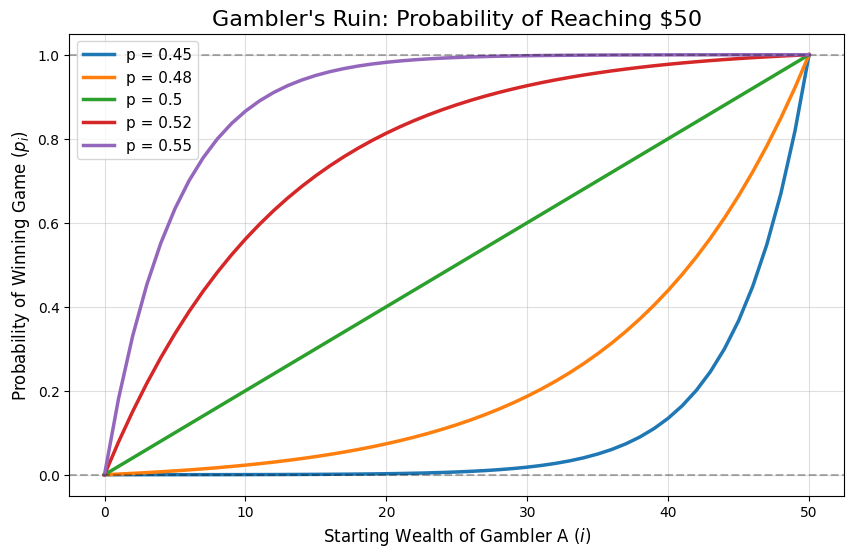

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_ruin_prob(i, N, p):
    """Calculates the probability of A reaching N before 0."""
    if p == 0.5:
        return i / N
    else:
        q = 1 - p
        return (1 - (q/p)**i) / (1 - (q/p)**N)

# Set up the game parameters
N = 50
i_values = np.arange(0, N+1)
probabilities_to_test = [0.45, 0.48, 0.50, 0.52, 0.55]

plt.figure(figsize=(10, 6))

# Plot the curve for each probability
for p in probabilities_to_test:
    probs = [calculate_ruin_prob(i, N, p) for i in i_values]
    plt.plot(i_values, probs, label=f'p = {p}', linewidth=2.5)

# Formatting
plt.title("Gambler's Ruin: Probability of Reaching $50", fontsize=16)
plt.xlabel("Starting Wealth of Gambler A ($i$)", fontsize=12)
plt.ylabel("Probability of Winning Game ($p_i$)", fontsize=12)
plt.axhline(y=1, color='k', linestyle='--', alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.4)

plt.show()
